# Medistar Vision — Geração do Dataset de Classificação

Este notebook documenta o processo de preparação do dataset utilizado no projeto Medistar Vision.

O dataset original contém imagens satelitais e máscaras segmentadas. Como a entrega de Applied Computer Vision exige um problema de classificação de imagens com CNNs treinadas do zero, o dataset foi adaptado para classificação por recortes.

Cada imagem original foi dividida em pequenos patches de 128x128 pixels. Para cada patch, a máscara correspondente foi analisada e a classe dominante foi usada como rótulo da imagem.

## Contexto

O Medistar é uma plataforma de telemedicina e vigilância em saúde voltada para regiões isoladas. A análise de imagens satelitais pode auxiliar a identificação do contexto territorial de uma comunidade, como presença de área urbana, vegetação densa, agricultura ou terreno exposto.

Essas informações podem apoiar a priorização de atendimentos, pois comunidades localizadas em áreas de floresta densa, regiões rurais ou locais com infraestrutura limitada podem apresentar maior dificuldade de acesso aos serviços de saúde.

In [1]:
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

In [2]:
RAW_IMAGES_DIR = Path("../data/raw/images")
RAW_LABELS_DIR = Path("../data/raw/labels")
PROCESSED_DIR = Path("../data/processed")
SAMPLE_DIR = Path("../data/sample")

PATCH_SIZE = 128
MIN_DOMINANT_RATIO = 0.60

CLASS_NAMES = {
    0: "urbano",
    1: "vegetacao_densa",
    2: "sombra",
    3: "vegetacao_esparsa",
    4: "agricultura",
    5: "rocha_original",
    6: "solo_exposto_original",
    7: "agua_original",
}

CLASS_COLORS = {
    0: (255, 0, 0),        # Urbano
    1: (38, 115, 0),       # Vegetação Densa
    2: (0, 0, 0),          # Sombra
    3: (133, 199, 126),    # Vegetação Esparsa
    4: (255, 255, 0),      # Agricultura
    5: (128, 128, 128),    # Rocha
    6: (139, 69, 19),      # Solo Exposto
    7: (84, 117, 168),     # Água
}

FINAL_CLASSES = [
    "urbano",
    "vegetacao_densa",
    "sombra",
    "vegetacao_esparsa",
    "agricultura",
    "terreno_exposto"
]

## Classes identificadas nas máscaras

As máscaras do dataset utilizam cores RGB para representar as classes. Após inspeção das labels, foram encontrados os seguintes mapeamentos:

| Classe original | Cor RGB | Interpretação |
|---|---|---|
| Urbano | `(255, 0, 0)` | Área construída ou urbanizada |
| Vegetação densa | `(38, 115, 0)` | Floresta ou vegetação fechada |
| Sombra | `(0, 0, 0)` | Área com baixa visibilidade |
| Vegetação esparsa | `(133, 199, 126)` | Vegetação menos densa |
| Agricultura | `(255, 255, 0)` | Área agrícola |
| Rocha | `(128, 128, 128)` | Classe original com aparência semelhante a solo exposto |
| Solo exposto | `(139, 69, 19)` | Área aberta, solo descoberto ou terreno exposto |
| Água | `(84, 117, 168)` | Rios, lagos ou corpos d'água |

In [3]:
image_paths = sorted(RAW_IMAGES_DIR.glob("*.tif"))
label_paths = sorted(RAW_LABELS_DIR.glob("*.png"))

print(f"Total de imagens originais: {len(image_paths)}")
print(f"Total de labels originais: {len(label_paths)}")

if image_paths:
    print("Exemplo de imagem:", image_paths[0].name)

if label_paths:
    print("Exemplo de label:", label_paths[0].name)

Total de imagens originais: 35
Total de labels originais: 35
Exemplo de imagem: raster01.tif
Exemplo de label: raster01.png


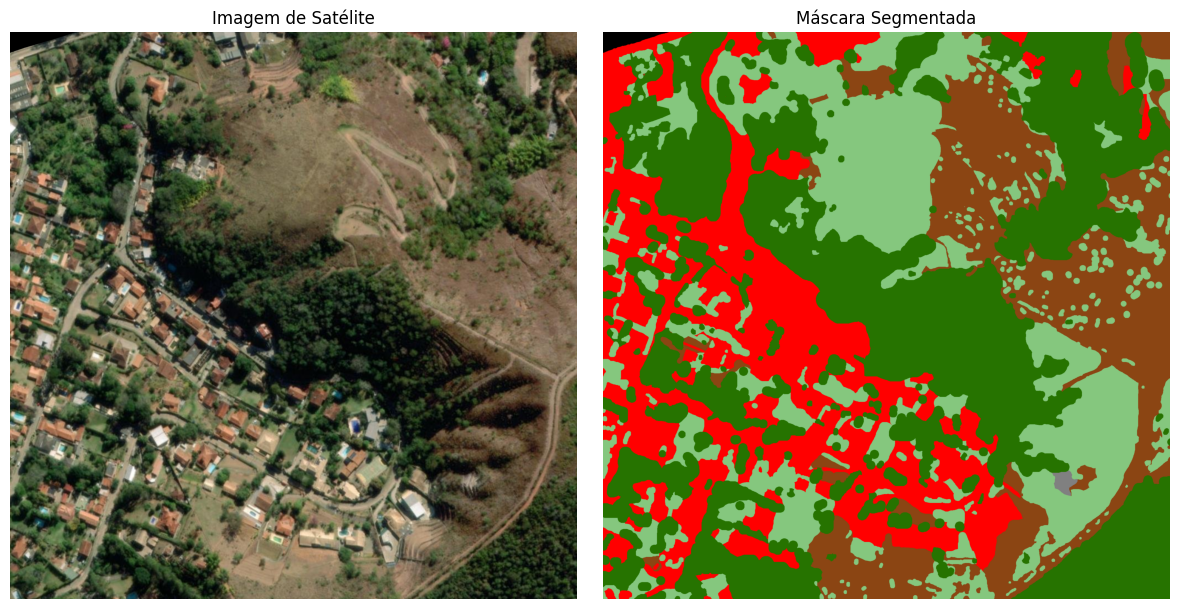

In [4]:
image_path = image_paths[0]
label_path = RAW_LABELS_DIR / f"{image_path.stem}.png"

image = Image.open(image_path).convert("RGB")
label = Image.open(label_path).convert("RGB")

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Imagem de Satélite")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(label)
plt.title("Máscara Segmentada")
plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
label_array = np.array(label)
pixels = label_array.reshape(-1, 3)

unique_colors, counts = np.unique(pixels, axis=0, return_counts=True)

print(f"Total de cores encontradas nesta label: {len(unique_colors)}")

for color, count in zip(unique_colors, counts):
    print(f"{tuple(color)} -> {count} pixels")

Total de cores encontradas nesta label: 6
(np.uint8(0), np.uint8(0), np.uint8(0)) -> 8808 pixels
(np.uint8(38), np.uint8(115), np.uint8(0)) -> 1601688 pixels
(np.uint8(128), np.uint8(128), np.uint8(128)) -> 4896 pixels
(np.uint8(133), np.uint8(199), np.uint8(126)) -> 1007901 pixels
(np.uint8(139), np.uint8(69), np.uint8(19)) -> 686612 pixels
(np.uint8(255), np.uint8(0), np.uint8(0)) -> 884399 pixels


In [6]:
all_colors_counter = Counter()

for label_path in label_paths:
    img = Image.open(label_path).convert("RGB")
    arr = np.array(img)
    pixels = arr.reshape(-1, 3)

    colors, counts = np.unique(pixels, axis=0, return_counts=True)

    for color, count in zip(colors, counts):
        all_colors_counter[tuple(color.tolist())] += int(count)

print("Cores gerais do dataset:")
print("-" * 60)

for color, count in all_colors_counter.most_common():
    print(f"{color} -> {count} pixels")

Cores gerais do dataset:
------------------------------------------------------------
(38, 115, 0) -> 48832463 pixels
(133, 199, 126) -> 34478066 pixels
(255, 0, 0) -> 19638982 pixels
(139, 69, 19) -> 18863121 pixels
(128, 128, 128) -> 10169115 pixels
(0, 0, 0) -> 8037622 pixels
(255, 255, 0) -> 5504682 pixels
(84, 117, 168) -> 1276589 pixels


## Decisões de preparação do dataset

Durante a inspeção visual e estatística do dataset, foram tomadas algumas decisões para melhorar a qualidade do problema de classificação:

1. **Remoção da classe Água**  
   A classe água apresentou baixa representatividade após a geração dos recortes, resultando em poucas amostras para treino, validação e teste. Para evitar desbalanceamento extremo, ela foi removida do experimento principal.

2. **Agrupamento de Rocha e Solo Exposto**  
   A classe originalmente identificada como rocha apresentou forte semelhança visual com regiões de solo descoberto. Por isso, as classes rocha e solo exposto foram agrupadas em uma nova classe chamada `terreno_exposto`.

3. **Uso de recortes 128x128**  
   As imagens originais possuem alta resolução. Para transformar o problema em classificação de imagens, as cenas foram divididas em patches de 128x128 pixels.

4. **Classe dominante mínima de 60%**  
   Cada patch recebeu o rótulo da classe dominante na máscara correspondente. Foram aceitos apenas recortes em que a classe dominante representava pelo menos 60% da área do patch.

In [7]:
def rgb_mask_to_class_ids(mask_rgb):
    height, width, _ = mask_rgb.shape
    class_mask = np.full((height, width), fill_value=-1, dtype=np.int16)

    for class_id, color in CLASS_COLORS.items():
        color_array = np.array(color)
        matches = np.all(mask_rgb == color_array, axis=-1)
        class_mask[matches] = class_id

    return class_mask


def get_dominant_class(mask_patch):
    valid_pixels = mask_patch[mask_patch >= 0]

    if len(valid_pixels) == 0:
        return None, 0

    class_ids, counts = np.unique(valid_pixels, return_counts=True)

    dominant_index = np.argmax(counts)
    dominant_class = int(class_ids[dominant_index])
    dominant_ratio = counts[dominant_index] / len(valid_pixels)

    return dominant_class, dominant_ratio

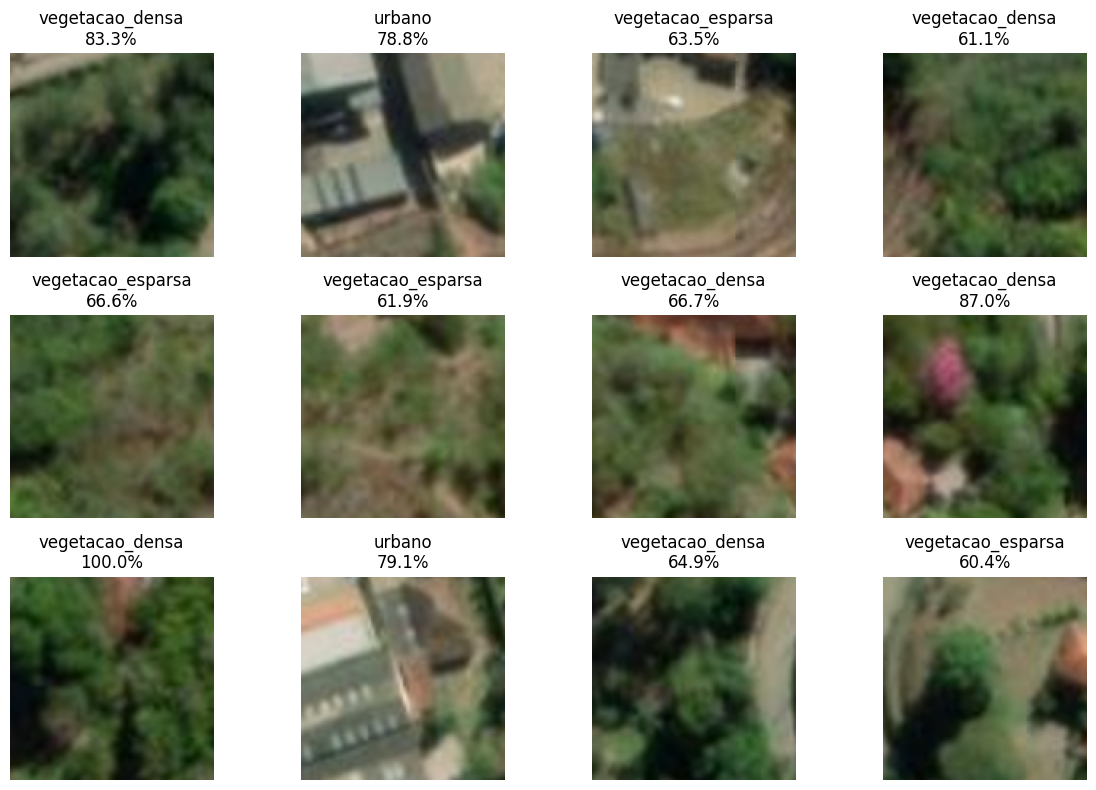

In [8]:
image_np = np.array(image)
label_np = np.array(label)

class_mask = rgb_mask_to_class_ids(label_np)

patches_to_show = []

for y in range(0, image_np.shape[0] - PATCH_SIZE + 1, PATCH_SIZE):
    for x in range(0, image_np.shape[1] - PATCH_SIZE + 1, PATCH_SIZE):
        image_patch = image_np[y:y + PATCH_SIZE, x:x + PATCH_SIZE]
        mask_patch = class_mask[y:y + PATCH_SIZE, x:x + PATCH_SIZE]

        dominant_class, dominant_ratio = get_dominant_class(mask_patch)

        if dominant_class is None:
            continue

        if dominant_class == 5:
            final_class_name = "terreno_exposto"
        elif dominant_class == 6:
            final_class_name = "terreno_exposto"
        elif dominant_class == 7:
            continue
        else:
            final_class_name = CLASS_NAMES[dominant_class]

        if dominant_ratio >= MIN_DOMINANT_RATIO:
            patches_to_show.append((image_patch, final_class_name, dominant_ratio))

        if len(patches_to_show) >= 12:
            break

    if len(patches_to_show) >= 12:
        break

plt.figure(figsize=(12, 8))

for i, (patch, class_name, ratio) in enumerate(patches_to_show):
    plt.subplot(3, 4, i + 1)
    plt.imshow(patch)
    plt.title(f"{class_name}\n{ratio:.1%}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
def count_images_by_split(processed_dir):
    summary = {}

    for split in ["train", "val", "test"]:
        split_dir = processed_dir / split
        summary[split] = {}

        for class_dir in sorted(split_dir.iterdir()):
            if class_dir.is_dir():
                total_images = len(list(class_dir.glob("*.png")))
                summary[split][class_dir.name] = total_images

    return summary


summary = count_images_by_split(PROCESSED_DIR)

for split, classes in summary.items():
    print(f"\n{split.upper()}")
    print("-" * 40)

    for class_name, total in classes.items():
        print(f"{class_name}: {total}")


TRAIN
----------------------------------------
agricultura: 190
sombra: 328
terreno_exposto: 560
urbano: 560
vegetacao_densa: 560
vegetacao_esparsa: 560

VAL
----------------------------------------
agricultura: 40
sombra: 70
terreno_exposto: 120
urbano: 120
vegetacao_densa: 120
vegetacao_esparsa: 120

TEST
----------------------------------------
agricultura: 42
sombra: 71
terreno_exposto: 120
urbano: 120
vegetacao_densa: 120
vegetacao_esparsa: 120


In [10]:
import pandas as pd

rows = []

for class_name in FINAL_CLASSES:
    train_count = summary["train"].get(class_name, 0)
    val_count = summary["val"].get(class_name, 0)
    test_count = summary["test"].get(class_name, 0)
    total = train_count + val_count + test_count

    rows.append({
        "Classe": class_name,
        "Treino": train_count,
        "Validação": val_count,
        "Teste": test_count,
        "Total": total
    })

df_summary = pd.DataFrame(rows)
df_summary

,Classe,Treino,Validação,Teste,Total
0,urbano,560,120,120,800
1,vegetacao_densa,560,120,120,800
2,sombra,328,70,71,469
3,vegetacao_esparsa,560,120,120,800
4,agricultura,190,40,42,272
5,terreno_exposto,560,120,120,800


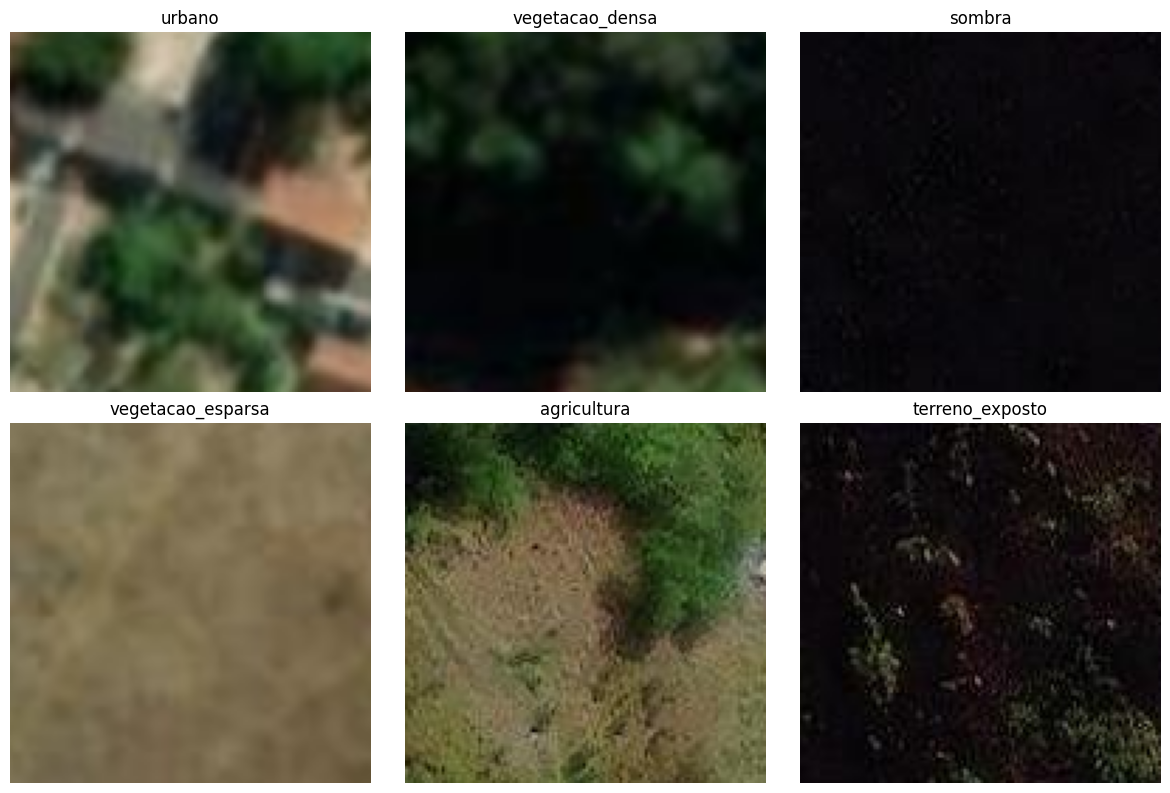

In [11]:
plt.figure(figsize=(12, 8))

plot_index = 1

for class_name in FINAL_CLASSES:
    class_dir = PROCESSED_DIR / "test" / class_name
    sample_images = list(class_dir.glob("*.png"))

    if not sample_images:
        continue

    sample_image = Image.open(sample_images[0]).convert("RGB")

    plt.subplot(2, 3, plot_index)
    plt.imshow(sample_image)
    plt.title(class_name)
    plt.axis("off")

    plot_index += 1

plt.tight_layout()
plt.show()

## Conclusão da preparação

O dataset original foi adaptado com sucesso para um problema de classificação de imagens satelitais.

A versão final utilizada no treinamento contém seis classes:

- `urbano`
- `vegetacao_densa`
- `sombra`
- `vegetacao_esparsa`
- `agricultura`
- `terreno_exposto`

Essa preparação permite treinar CNNs do zero para identificar características territoriais relevantes ao Medistar Vision. As classes finais representam elementos úteis para análise de comunidades isoladas, como infraestrutura urbana, presença de vegetação, áreas rurais e terreno exposto.